In [22]:
import Kea
from Kea.utils import plotting, funcs
from Kea.simulator import fbm
from Kea.statistics import statistics_base, moments
from Kea.statistics.spectra import strfn_spectra, spectra_base, arevalo_spectra, per_spectra
from Kea.statistics.statfunc import strfn, statfunc_base, statfunc_mpi_naive
from Kea.fitting import fit_base

c = plotting.COLOR_CYCLE_6

import matplotlib as mpl
plotting.modify_rc()
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

import numpy as np

D = 2
N = 256
L = 2.*np.pi
grid_dims = [N for _ in range(D)]
phys_dims = [L for _ in range(D)]

twopi = 2.*np.pi
dk = twopi/L
dx = L/N

/home/m/Documents/science_codes/Kea/Kea/utils/funcs.py:42: RuntimeWarning: divide by zero encountered in reciprocal
  pl = xx**(alphas[0])
/home/m/Documents/science_codes/Kea/Kea/utils/funcs.py:42: RuntimeWarning: divide by zero encountered in power
  pl = xx**(alphas[0])
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/Documents/science_codes/Kea/Kea/utils/funcs.py:42: RuntimeWarning: divide by zero encountered in power
  pl = xx**(alphas[0])
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  result[vv, i] = stat_func(np.array(bin_map[i]))
/home/m/Documents/science_codes/Kea/Kea/utils/funcs.py:42: RuntimeWarning: divide by zero encountered in power
  pl = xx**(alphas[0])
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:665: RuntimeWarning: Mean of empty slice
  res

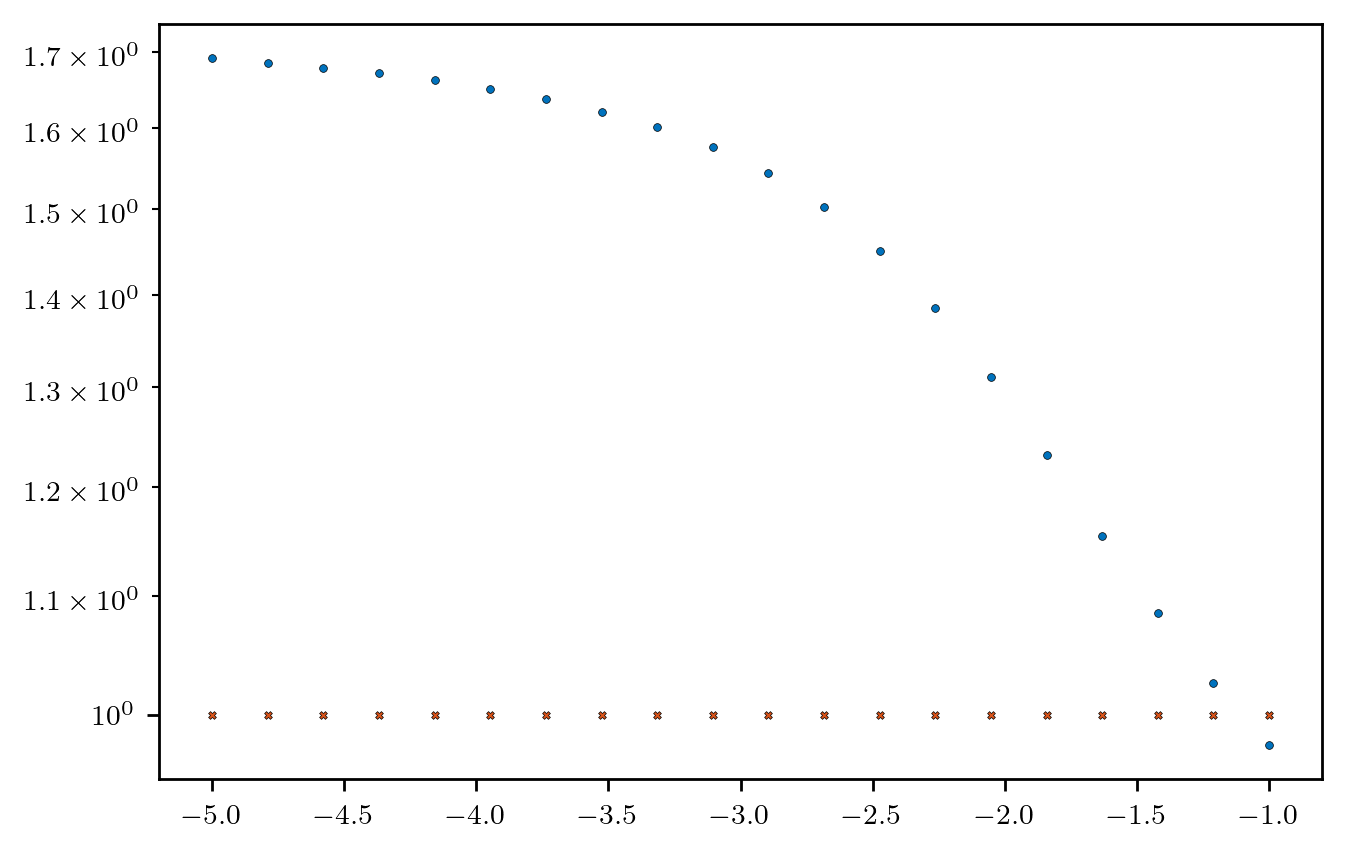

In [23]:
amin, amax = -(D+3.), -1.
NUM = 20
alphas = np.linspace(amax, amin, NUM)
np.random.seed(1234)
fields = []
for a in alphas:
    fields.append(fbm.create_fbm(grid_dims, phys_dims, (a,)))
energies = []
for f in fields:
    energies.append(moments.var(f, lenn=phys_dims))

specs = []
Pspecs = []
for i, f in enumerate(fields):
    #kD, fekD = per_spectra.modal_spectrum(f, phys_dims=phys_dims)
    #_km, _fekm, width = statistics_base.bin_data(spectra_base.wavenumber_mesh(kD), fekD,
    #        bin_func=np.nanmean, min_bin=dk, max_bin=None,
    #        ignore_nan=False, norm_bin_size=False, bin_loc='center',
    #        cut_excess=True, nan_small=False)#, num_bins=N//8, log_space=True)
    #Pspecs.append((_km, _fekm))
    kD, fekD = per_spectra.modal_spectrum(f, phys_dims=phys_dims)
    kmesh = spectra_base.wavenumber_mesh(kD)
    fekD_model = funcs.pure_pow(kmesh, (alphas[i],))
    var = np.nansum(fekD_model * (dk/twopi)**D)
    fekD_model = fekD_model / var
    _km, fek_model, width = statistics_base.bin_data(kmesh, fekD_model,
            bin_func=np.nanmean, min_bin=dk, max_bin=None,
            ignore_nan=False, norm_bin_size=False, bin_loc='true_center',
            cut_excess=True, nan_small=False)
    Pspecs.append((_km, fek_model, width))

    lags = arevalo_spectra.k_to_discrete_lags(_km, N, L, D)
    km, fekm = arevalo_spectra.modal_spectrum(f, lenn=phys_dims, lags=lags, mode='wrap')
    specs.append((km, fekm))

    e_parsevals = np.nansum(statistics_base.kern(km, D, width, dk) * fekm * (dk/twopi)**D)

    # * (dk/twopi)**D
    plt.scatter(alphas[i], e_parsevals, marker='o', s=5., color=c[0], zorder=2, linewidth=0.2, edgecolor='black')
    plt.scatter(alphas[i], energies[i], marker='X', s=5., color=c[1], zorder=2, linewidth=0.2, edgecolor='black')
    #assert np.isclose(e_parsevals / energies[i], 1., rtol=0.001), e_parsevals / energies[i]

plt.yscale('log')
#plt.ylim((9e-1, 1.1e0))

Text(0.5, 0, 'Wavenumber, $k_{\\sigma}$')

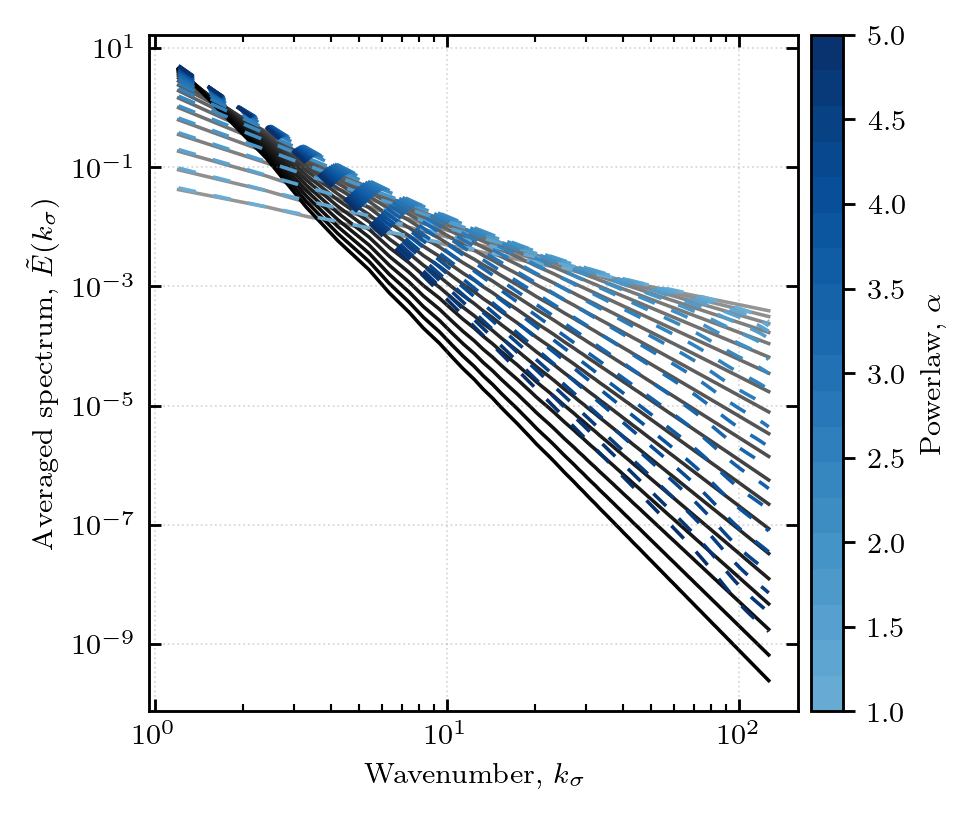

In [24]:
fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5), dpi=256)

cols = plt.cm.Blues(np.linspace(0.5, 1., NUM))
upper_cmap = mpl.colors.LinearSegmentedColormap.from_list('Upper', cols)
cols2 = plt.cm.Greys(np.linspace(0.5, 1., NUM))

for i in range(len(specs)):
    _k, _fek = specs[i]
    ax.plot(_k, _fek, color=cols[i], linewidth=1., zorder=2, linestyle=(0, (5,5)))

    ax.plot(Pspecs[i][0], Pspecs[i][1], color=cols2[i], linewidth=1., zorder=0)

ax.set_yscale('log')
ax.set_xscale('log')

ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='5%', pad=0.05)

sm = plt.cm.ScalarMappable(cmap=upper_cmap, norm=mpl.colors.Normalize(-amax, -amin))
cbar = fig.colorbar(sm, cax=cax, boundaries=np.linspace(-amax, -amin, NUM), ticks=np.arange(-amax, -amin+1., 0.5))

cbar.ax.set_ylabel('Powerlaw, $\\alpha$')

ax.set_ylabel('Averaged spectrum, $\\tilde{E}(k_{\sigma})$')
ax.set_xlabel('Wavenumber, $k_{\sigma}$')

In [25]:
cols = plt.get_cmap('Greys')(np.linspace(0.25, 1., NUM))
cols2 = plt.cm.Blues(np.linspace(0.25, 1., NUM))
cols3 = plt.cm.Greens(np.linspace(0.25, 1., NUM))
upper_cmap = mpl.colors.LinearSegmentedColormap.from_list('Upper', cols2)

Text(0.5, 0, 'Wavenumber, $k$')

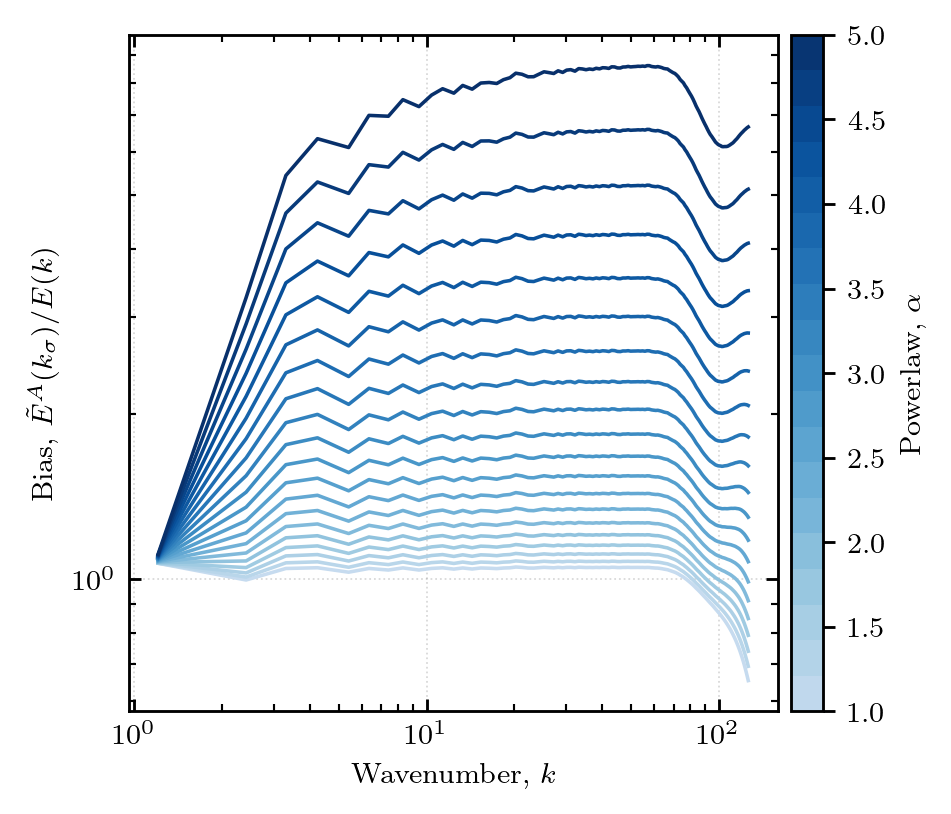

In [26]:
fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5), dpi=256)

bias = []

for i in range(len(specs)):
    pk, pfek, _w = Pspecs[i]
    ak, afek = specs[i]
    ax.plot(ak, afek / pfek, linewidth=1., color=cols2[i])#, color=cols2[i], linewidth=0.5, marker='X', markersize=2.5, zorder=2, markeredgewidth=0.2, markeredgecolor='black')
    bias.append((ak, afek/pfek))

ax.set_yscale('log')
ax.set_xscale('log')

#ax.axvline(BREAK, linestyle=(0,(5,5)), linewidth=1., color='gray')

ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='5%', pad=0.05)

sm = plt.cm.ScalarMappable(cmap=upper_cmap, norm=mpl.colors.Normalize(-amax, -amin))
cbar = fig.colorbar(sm, cax=cax, boundaries=np.linspace(-amax, -amin, NUM), ticks=np.arange(-amax, -amin+1., 0.5))

cbar.ax.set_ylabel('Powerlaw, $\\alpha$')

ax.set_ylabel('Bias, $\\tilde{E}^A(k_\sigma)/E(k)$')
ax.set_xlabel('Wavenumber, $k$')

Text(0.5, 0, 'Powerlaw, $\\alpha$')

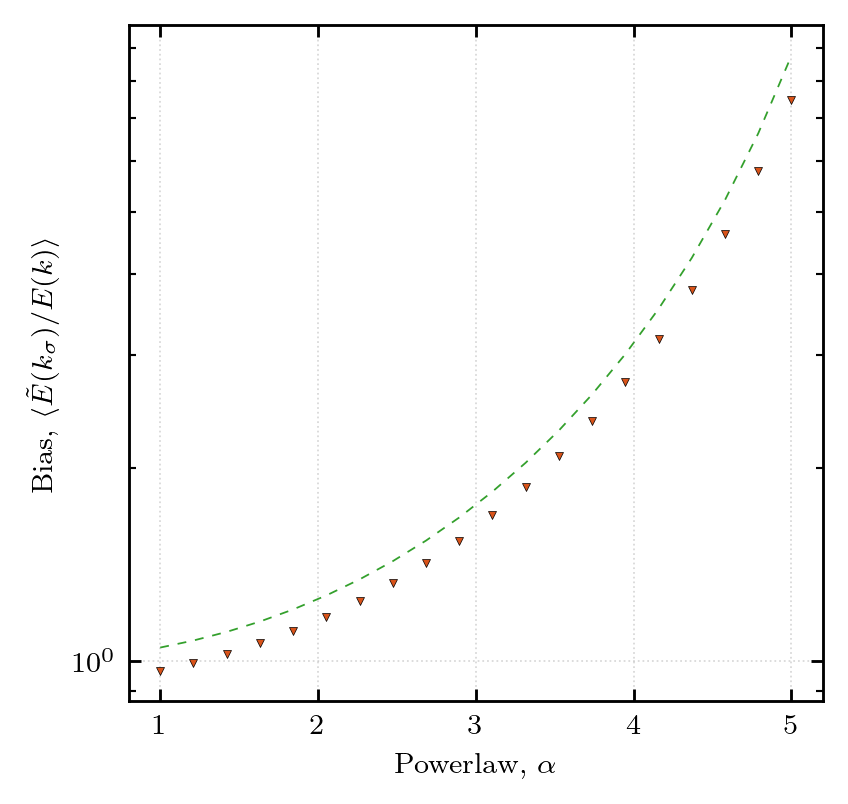

In [27]:
fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5), dpi=256)

from scipy.special import gamma
aa = -alphas
#scaling = 2.**(aa/2.) * (D+3.)**(aa/2.) * gamma(D/2. + 2. - aa/2.) / gamma(D/2. + 2.)
scaling = 2.**(-aa/2.) * (D+3.)**(aa/2.) * gamma(D/2. + 2. - aa/2.) / gamma(D/2. + 2.)
ax.plot(-alphas, scaling - 0., linewidth=0.5, color=c[2], linestyle=(0,(5,5)), zorder=0)

for i in range(len(specs)):
    pk, pfek, _w = Pspecs[i]
    ak, afek = specs[i]
    ax.scatter(-alphas[i], np.nanmean(afek / pfek), marker='v', s=5., color=c[1], zorder=2, linewidth=0.2, edgecolor='black')

ax.set_yscale('log')

ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

ax.set_ylabel('Bias, $\langle \\tilde{E}(k_{\sigma})/E(k) \\rangle$')
ax.set_xlabel('Powerlaw, $\\alpha$')

In [28]:
IDX = 8

from scipy.special import jv
import sympy as sp
sp.init_printing(use_latex='mathjax')

k = sp.symbols('k', postive=True, real=True)

sp_D = sp.symbols('D', positive=True, integer=True)
sp_D = 2

a = -alphas[IDX]
print('alpha', a)
#a = sp.symbols('a', postive=True, real=True)

sp_L = sp.symbols('L', positive=True, real=True)
sp_L = sp.S(5)*sp.pi

sp_kmin = (sp.S(2)*sp.pi/sp_L)
sp_kmax = (sp.pi*sp.S(N)/sp_L)

sp_E = sp.Piecewise(
    (0, k < sp_kmin),
    (0, k > sp_kmax),
    (k**(-a), True)
)

sig = sp.integrate(sp.S(2) * (sp.S(2) * sp.pi * k * sp_E) / (sp.S(2)*sp.pi)**2, (k, 0, sp.oo))
Ef = sp_E / sig
display(sp.integrate(sp.S(2) * (sp.S(2) * sp.pi * k * Ef) / (sp.S(2)*sp.pi)**2, (k, 0, sp.oo)))

s = sp.symbols('sigma', real=True, positive=True)
xi = sp.symbols('xi', real=True, positive=True)

Hk = k**2 * s**2 * xi * sp.exp(- k**2 * s**2 / 2)

S_D = sp.S(2)*sp.pi

#S_D = sp.S(4)*sp.pi

norm = sp.S(1)/(sp.S(2)*sp.pi)**sp_D

Vs_num = sp.S(2) * norm * sp.integrate((S_D * k**(sp_D-1)) * Ef * sp.Abs(Hk)**2, (k, 0, sp.oo))

Vs_denom = sp.S(2) * norm * sp.integrate((S_D * k**(sp_D-1)) * sp.Abs(Hk)**2, (k, 0, sp.oo))
Vs = Vs_num / Vs_denom

display(Vs_num)
display(Vs_denom)
display(Vs)


alpha 2.6842105263157894


1.00000000000000

                                              ⎛                     2⎞        
                     2  0.684210526315789  2  ⎜                  4⋅σ ⎟        
- 0.379236321402615⋅π ⋅σ                 ⋅ξ ⋅γ⎜1.65789473684211, ────⎟ + 0.379
                                              ⎝                   25 ⎠        
──────────────────────────────────────────────────────────────────────────────
                                                                          2   
                                                                       2⋅π    

                                       ⎛                         2⎞
              2  0.684210526315789  2  ⎜                  65536⋅σ ⎟
236321402615⋅π ⋅σ                 ⋅ξ ⋅γ⎜1.65789473684211, ────────⎟
                                       ⎝                     25   ⎠
───────────────────────────────────────────────────────────────────
                                                                   
                                      

  2 
 ξ  
────
   2
π⋅σ 

   ⎛                                              ⎛                     2⎞    
 2 ⎜                     2  0.684210526315789  2  ⎜                  4⋅σ ⎟    
σ ⋅⎜- 0.379236321402615⋅π ⋅σ                 ⋅ξ ⋅γ⎜1.65789473684211, ────⎟ + 0
   ⎝                                              ⎝                   25 ⎠    
──────────────────────────────────────────────────────────────────────────────
                                                                             2
                                                                        2⋅π⋅ξ 

                                           ⎛                         2⎞⎞
                  2  0.684210526315789  2  ⎜                  65536⋅σ ⎟⎟
.379236321402615⋅π ⋅σ                 ⋅ξ ⋅γ⎜1.65789473684211, ────────⎟⎟
                                           ⎝                     25   ⎠⎠
────────────────────────────────────────────────────────────────────────
                                                                        
        

/tmp/ipykernel_27574/3134469501.py:9: RuntimeWarning: divide by zero encountered in double_scalars
  ax.scatter(_k, num/denom, marker='o', s=5., color=c[0], zorder=2, linewidth=0.2, edgecolor='black')


Text(0.5, 0, 'Wavenumber, $k_{\\sigma}$')

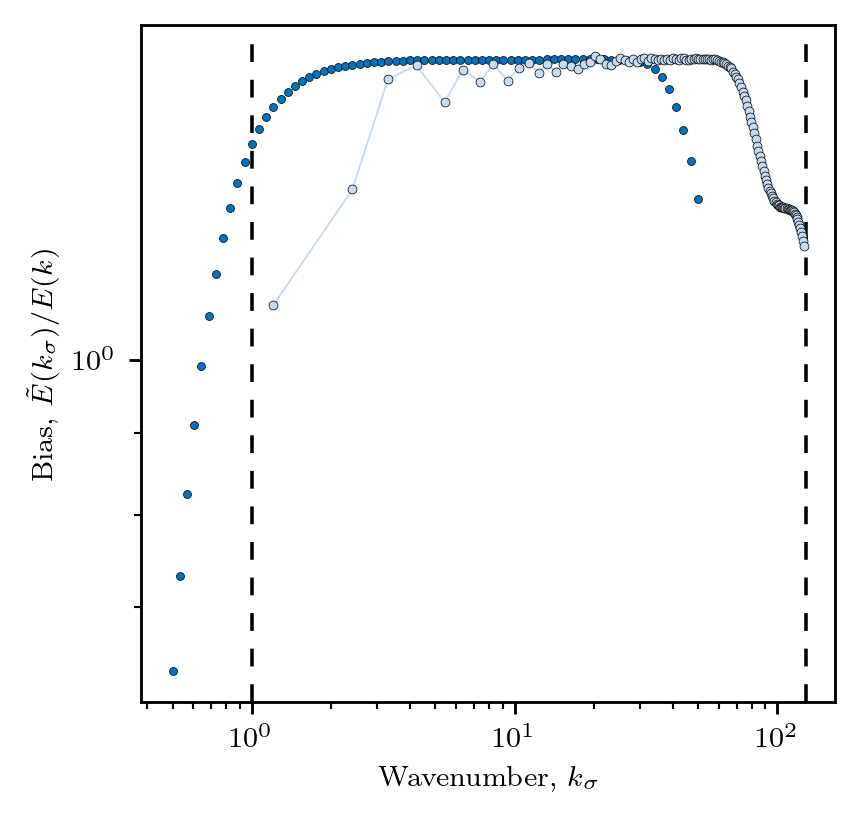

In [29]:
fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5), dpi=256)

lam_E = sp.lambdify(k, Ef, modules=['scipy', 'numpy'])
lam_V = sp.lambdify(s, Vs.subs({xi: 1e-3}), modules=['scipy', 'numpy'])
for _k in np.exp(np.linspace(np.log(np.pi/L), np.log(2*N*np.pi/L), 100)):
    _s = np.sqrt(2.*D + 6.)/(2.*_k)
    num = lam_V(_s)
    denom = lam_E(_k)
    ax.scatter(_k, num/denom, marker='o', s=5., color=c[0], zorder=2, linewidth=0.2, edgecolor='black')

ax.plot(bias[IDX][0], bias[IDX][1], linewidth=0.5, color=cols2[0], marker='o', markersize=2.5, zorder=3, markeredgewidth=0.2, markeredgecolor='black')

ax.loglog()

ax.axvline(2.*np.pi/L, color='black', linewidth=1., linestyle=(0,(5,5)), zorder=0)
ax.axvline(np.pi*N/L, color='black', linewidth=1., linestyle=(0,(5,5)), zorder=0)

ax.set_ylabel('Bias, $\\tilde{E}(k_{\sigma})/E(k)$')
ax.set_xlabel('Wavenumber, $k_{\sigma}$')

In [30]:
def analytical_bias(a):
    sp_k = sp.symbols('k', postive=True, real=True)
    sp_D = 2
    sp_L = sp.S(5)*sp.pi
    sp_kmin = (sp.S(2)*sp.pi/sp_L)
    sp_kmax = (sp.pi*sp.S(N)/sp_L)
    sp_E = sp.Piecewise(
        (0, sp_k < sp_kmin),
        (0, sp_k > sp_kmax),
        (sp_k**(-a), True)
    )
    Ef = sp_k**(-a)
    #sig = sp.integrate(sp.S(2) * (sp.S(2) * sp.pi * sp_k * sp_E) / (sp.S(2)*sp.pi)**2, (sp_k, 0, sp.oo))
    #Ef = sp_E / sig
    s = sp.symbols('sigma', real=True, positive=True)
    xi = sp.symbols('xi', real=True, positive=True)
    Hk = sp_k**2 * s**2 * xi * sp.exp(- sp_k**2 * s**2 / 2)
    S_D = sp.S(2)*sp.pi**(sp_D)
    norm = sp.S(1)/(sp.S(2)*sp.pi)**sp_D
    Vs_num = sp.S(2) * norm * sp.integrate((S_D * sp_k**(sp_D-1)) * Ef * sp.Abs(Hk)**2, (sp_k, 0, sp.oo))
    Vs_denom = sp.S(2) * norm * sp.integrate((S_D * sp_k**(sp_D-1)) * sp.Abs(Hk)**2, (sp_k, 0, sp.oo))
    Vs = Vs_num / Vs_denom
    _ks = []
    _bias = []
    lam_E = sp.lambdify(sp_k, Ef, modules=['scipy', 'numpy'])
    lam_V = sp.lambdify(s, Vs.subs({xi: 1e-3}), modules=['scipy', 'numpy'])
    for _k in np.linspace(2.*np.pi/L, N*np.pi/L, 100):
        _s = np.sqrt(2.*D + 6.)/(2.*_k)
        num = lam_V(_s)
        denom = lam_E(_k)
        _ks.append(_k)
        _bias.append(num/denom)
    return np.array(_ks), np.array(_bias)

Text(0.5, 0, 'Wavenumber, $k$')

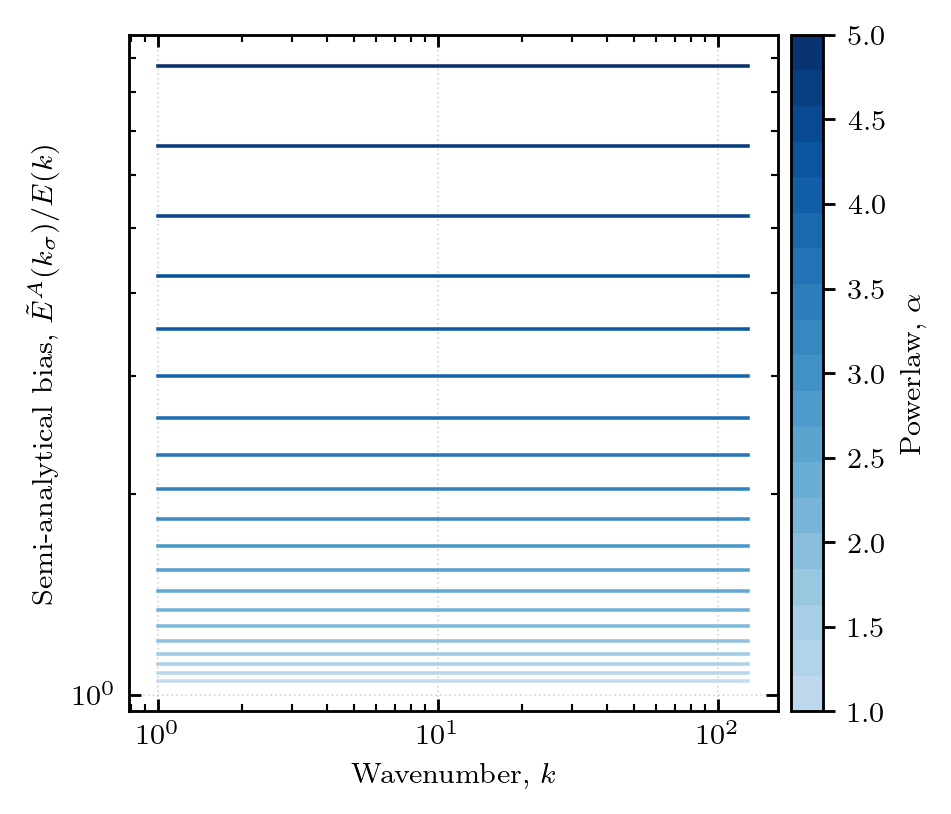

In [31]:
fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5), dpi=256)

for i, a in enumerate(alphas):
    k, b = analytical_bias(-a)
    ax.plot(k, b, linewidth=1., color=cols2[i])

ax.set_yscale('log')
ax.set_xscale('log')

ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='5%', pad=0.05)

sm = plt.cm.ScalarMappable(cmap=upper_cmap, norm=mpl.colors.Normalize(-amax, -amin))
cbar = fig.colorbar(sm, cax=cax, boundaries=np.linspace(-amax, -amin, NUM), ticks=np.arange(-amax, -amin+1., 0.5))

cbar.ax.set_ylabel('Powerlaw, $\\alpha$')

ax.set_ylabel('Semi-analytical bias, $\\tilde{E}^A(k_\sigma)/E(k)$')
ax.set_xlabel('Wavenumber, $k$')

Text(0.5, 0, 'Powerlaw, $\\alpha$')

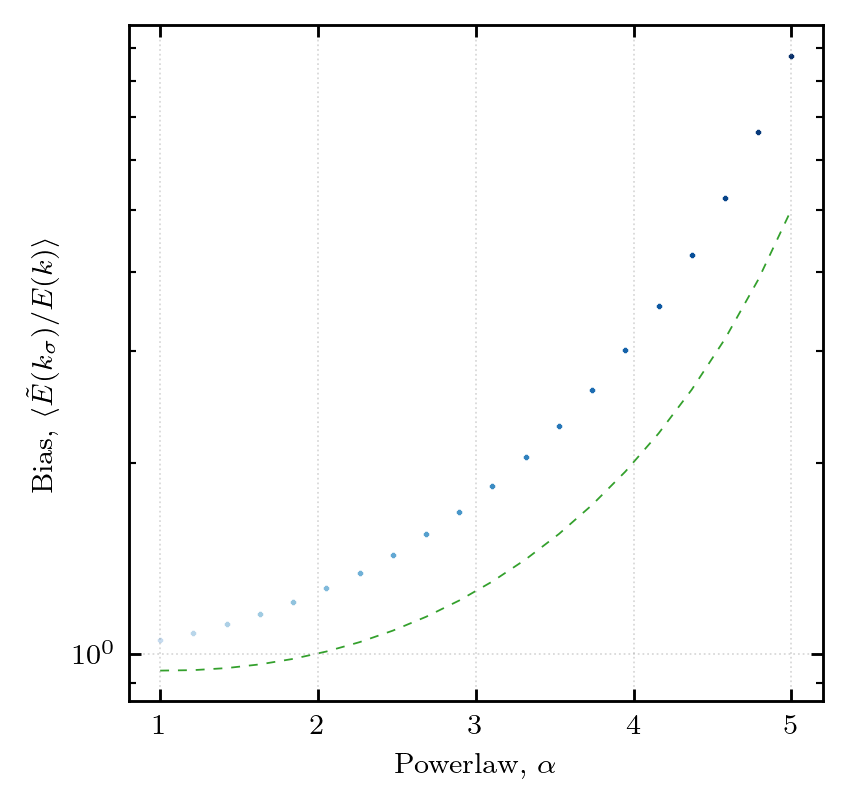

In [32]:
fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5), dpi=256)

from scipy.special import gamma
aa = -alphas
scaling = 2.**(aa/2.) * gamma(D/2. + 2. - aa/2.) / gamma(D/2. + 2.)
ax.plot(-alphas, scaling - 0., linewidth=0.5, color=c[2], linestyle=(0,(5,5)), zorder=0)

for i, a in enumerate(alphas):
    k, b = analytical_bias(-a)
    ax.scatter(-a, np.nanmean(b), linewidth=1., color=cols2[i], s=1., marker='x')

ax.set_yscale('log')

ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

ax.set_ylabel('Bias, $\langle \\tilde{E}(k_{\sigma})/E(k) \\rangle$')
ax.set_xlabel('Powerlaw, $\\alpha$')

In [33]:
# def gaussian_kernel1d(sig, dx, dsig, M=None):
#     sigma = float(sig) * dsig
#     if M is None:
#         M = int(5. * sig + 0.5)
#     n = np.arange(-M, M+1, 1)
#     x = n * dx
#     return np.exp(-x**2 / (2. * sigma**2))/np.sqrt(2. * np.pi * sigma**2)

In [34]:
# lags = arevalo_spectra.k_to_discrete_lags(Pspecs[0][0], N, L)
# IDX = -1
# f = gaussian_kernel1d(lags[IDX], dx, dx*np.sqrt(2.)/np.pi, N)
# #plt.plot(np.arange(-N, N+1, 1), f)
# from scipy import ndimage
# f2 = ndimage._filters._gaussian_kernel1d(lags[IDX]*np.sqrt(2.)/np.pi, 0, N)
# plt.plot(np.arange(-N, N+1, 1), f/f2, linestyle=(0,(5,5)))
# print('k', Pspecs[0][0][IDX])
# plt.loglog()

In [35]:
# def gaussian_kernel1d(sig, dx, dsig, M=None):
#     ## TODO: STILL NEED TO TAKE sig=1
#     sigma = float(sig) * dsig
#     if M is None:
#         M = int(5. * sig + 0.5)
#     n = np.arange(-M, M+1, 1)
#     x = n * dx
#     #return np.exp(-x**2 / (2. * sigma**2))/np.sqrt(2. * np.pi * sigma**2)
#     phi_x = np.exp(-x**2 / (2. * sigma**2))
#     return np.sqrt(2.*np.pi*sigma**2)/np.sum(phi_x)

In [36]:
# lags = arevalo_spectra.k_to_discrete_lags(Pspecs[0][0], N, L)
# for l in lags:
#     ra = gaussian_kernel1d(l, dx, dx*np.sqrt(2.)/np.pi, None)
#     plt.scatter(l, ra, marker='o', s=5., color=c[0], zorder=2, linewidth=0.2, edgecolor='black')
# plt.loglog()

In [37]:
# IDX = 13

# from scipy.special import jv
# import sympy as sp
# sp.init_printing(use_latex='mathjax')

# k = sp.symbols('k', postive=True, real=True)

# a = -alphas[IDX]
# print(a)
# #a = sp.symbols('a', postive=True, real=True)

# sp_kmin = (2.*sp.pi/L)
# sp_kmax = (sp.pi*N/L)

# sp_E = sp.Piecewise(
#     (0, k < sp_kmin),
#     (0, k > sp_kmax),
#     (k**(-a), True)
# )

# sig = sp.integrate(2. * (2. * sp.pi * k * sp_E) / (2.*sp.pi)**2, (k, 0., sp.oo))
# Ef = sp_E / sig

# s = sp.symbols('s', real=True, positive=True)
# xi = 1e-3

# Hk = k**2 * s**2 * xi * sp.exp(- k**2 * s**2 / 2.)

# from scipy.special import gamma as G

# S_D = 2.*sp.pi**(D/2)/G(D/2)
# norm = 1./(2.*sp.pi)**D

# Vs_num = 2. * norm * sp.integrate((S_D * k**(D-1)) * Ef * sp.Abs(Hk)**2, (k, 0., sp.oo))
# Vs_denom = 2. * norm * sp.integrate((S_D * k**(D-1)) * sp.Abs(Hk)**2, (k, 0., sp.oo))
# Vs = Vs_num / Vs_denom

# display(Vs_num)
# display(Vs_denom)
# display(Vs)

# Es = Ef.subs({k: sp.sqrt(2.) / s})

# Vs_num2 = 2. * norm * Es * sp.integrate((S_D * k**(D-1)) * sp.Abs(Hk)**2, (k, 0., sp.oo))
# Vs_denom2 = 2. * norm * sp.integrate((S_D * k**(D-1)) * sp.Abs(Hk)**2, (k, 0., sp.oo))
# Vs2 = Vs_num2 / Vs_denom2

# display(Vs_num2)
# display(Vs_denom2)
# display(Vs2)

# display(Vs/Vs2)

In [38]:
# D = sp.symbols('D', positive=True, real=True)
# S_D = 2.*sp.pi**(D/2)/sp.gamma(D/2)
# norm = 1./(2.*sp.pi)**D
# xi = sp.symbols('xi', positive=True, real=True)
# Hk = k**2 * s**2 * xi * sp.exp(- k**2 * s**2 / 2.)
# Vs_denom = sp.integrate((S_D * k**(D-1)) * sp.Abs(Hk)**2, (k, 0., sp.oo))
# display(Vs_denom)

In [39]:
# from scipy.special import jv
# import sympy as sp
# sp.init_printing(use_latex='mathjax')

# k, l = sp.symbols('k l', positive=True, real=True)

# s = sp.symbols('s', real=True, positive=True)
# D = sp.symbols('D', integer=True, positive=True)
# xi = sp.symbols('xi', real=True, positive=True)

# a = sp.symbols('a', positive=True, real=True)
# Kl, Kh = sp.symbols('Kl Kh', positive=True, real=True)

# a = -alphas[IDX]
# print('POWERLAW', a)
# Kl = np.nanmin(k_true)
# Kh = np.nanmax(k_true)
# D = 2
# xi = 1e-3

# E = sp.Piecewise(
#     (1, k < Kl),
#     (0, k >= Kh),
#     (k**(-a), True)
# )

# S_D = 2*sp.pi**(D/2)/sp.gamma(D/2)
# norm = 1/(2*sp.pi)**D

# E_H = sp.Abs(k**2 * s**2 * xi * sp.exp(-k**2 * s**2 / 2))**2

# dk = 2.*sp.pi/L

# VAR_s = dk**D * norm * S_D * sp.integrate(E * E_H * k**(D - 1), (k, 0, sp.oo))

# display(VAR_s)
